In [18]:
#!/usr/bin/env python3

# Import necessary libraries
# - os, pathlib: File and path handling
# - h5py: HDF5 file reading (trajectory data)
# - json: Metadata parsing
# - numpy: Numerical operations
# - matplotlib: Plotting and visualization
# - cv2: Video processing with OpenCV
# - IPython.display: Rich display in notebook
# - mpl_toolkits.mplot3d: 3D plotting

import os
import h5py
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
from IPython.display import display, HTML
from mpl_toolkits.mplot3d import Axes3D

# Import our custom utility functions
from utils.data_loading import load_traj_from_HDF5


In [19]:
# Configuration
# ============================================================================
# This cell sets up the path to the episode we want to analyze
# The episode should be in the VJEPA2-AC format with:
# - metadata.json: Episode metadata
# - trajectory.h5: Robot state and action data
# - recordings/MP4/: Video recordings

# Path to a transformed episode (update this to point to your episode)
EPISODE_PATH = "/teamspace/studios/this_studio/test_dataset/output/smanni+train_so100_all-episode_001"

VJEPA2-AC Trajectory Explorer
Exploring episode: /teamspace/studios/this_studio/test_dataset/output/smanni+train_so100_all-episode_001


In [20]:
def explore_episode_structure(episode_path):
    """
    Explore the structure of a VJEPA2-AC episode
    
    This function examines the episode directory structure and prints information about:
    - metadata.json: Contains episode information like video paths
    - trajectory.h5: Contains robot state and action data
    - video files: MP4 recordings of the episode
    
    Args:
        episode_path: Path to the episode directory
        
    Returns:
        dict: Dictionary containing episode metadata and data references
    """
    print(f"\nExploring episode structure: {os.path.basename(episode_path)}")
    print("=" * 60)
    
    if not os.path.exists(episode_path):
        print(f"ERROR: Episode path does not exist: {episode_path}")
        return None
    
    episode_info = {
        'path': episode_path,
        'name': os.path.basename(episode_path),
        'metadata': None,
        'trajectory': None,
        'videos': []
    }
    
    # Check for metadata.json
    metadata_path = os.path.join(episode_path, 'metadata.json')
    if os.path.exists(metadata_path):
        try:
            with open(metadata_path, 'r') as f:
                episode_info['metadata'] = json.load(f)
            print(f"[FOUND] metadata.json ({os.path.getsize(metadata_path)} bytes)")
        except Exception as e:
            print(f"[ERROR] Failed to load metadata.json: {e}")
    else:
        print(f"[MISSING] metadata.json")
    
    # Check for trajectory.h5
    trajectory_path = os.path.join(episode_path, 'trajectory.h5')
    if os.path.exists(trajectory_path):
        try:
            with h5py.File(trajectory_path, 'r') as f:
                # Store reference to file path
                episode_info['trajectory'] = trajectory_path
                
                # Print structure
                print(f"[FOUND] trajectory.h5 ({os.path.getsize(trajectory_path) / 1024:.1f} KB)")
                print("\nTrajectory structure:")
                
                def print_h5_structure(item, prefix=''):
                    if isinstance(item, h5py.Group):
                        print(f"{prefix}Group: {item.name}")
                        for key in item.keys():
                            print_h5_structure(item[key], prefix + '  ')
                    elif isinstance(item, h5py.Dataset):
                        print(f"{prefix}Dataset: {item.name}")
                        print(f"{prefix}   Shape: {item.shape}, Type: {item.dtype}")
                
                print_h5_structure(f)
        except Exception as e:
            print(f"[ERROR] Failed to load trajectory.h5: {e}")
    else:
        print(f"[MISSING] trajectory.h5")
    
    # Check for videos
    recordings_path = os.path.join(episode_path, 'recordings', 'MP4')
    if os.path.exists(recordings_path):
        video_files = [f for f in os.listdir(recordings_path) if f.lower().endswith('.mp4')]
        episode_info['videos'] = video_files
        
        print(f"\n[FOUND] {len(video_files)} video file(s) in recordings/MP4/")
        for video in video_files:
            video_path = os.path.join(recordings_path, video)
            print(f"   - {video} ({os.path.getsize(video_path) / (1024*1024):.1f} MB)")
    else:
        print(f"[MISSING] recordings/MP4/ directory")
    
    return episode_info


In [21]:
def load_trajectory_data(episode_info):
    """
    Load trajectory data from the episode's HDF5 file
    
    This function extracts:
    - Cartesian positions: End-effector position (XYZ) and orientation (quaternion)
    - Gripper positions: State of the robot's gripper
    - Actions: Robot actions if available
    - Timestamps: Time points for each data point
    
    The expected HDF5 structure follows VJEPA2-AC format:
    - /observation/robot_state/cartesian_position: End-effector pose
    - /observation/robot_state/gripper_position: Gripper state
    - /action: Robot actions
    - /observation/timestamps: Time data
    
    Args:
        episode_info: Dictionary containing episode information
        
    Returns:
        dict: Dictionary containing trajectory data components
    """
    if not episode_info or not episode_info['trajectory']:
        print("No trajectory data available")
        return None
    
    trajectory_path = episode_info['trajectory']
    
    try:
        # Use our utility function to load trajectory data
        traj_data = load_traj_from_HDF5(trajectory_path)    
        # Extract the specific components needed for this notebook
        cartesian_positions = traj_data.get('cartesian_position')
        if cartesian_positions is not None:
            print(f"Loaded cartesian positions with shape: {cartesian_positions.shape}")
        
        gripper_positions = traj_data.get('gripper_position')
        if gripper_positions is not None:
            print(f"Loaded gripper positions with shape: {gripper_positions.shape}")
        
        actions = traj_data.get('actions')
        if actions is not None:
            print(f"Loaded actions with shape: {actions.shape}")
        
        timestamps = traj_data.get('timestamps')
        if timestamps is not None:
            print(f"Loaded timestamps with shape: {timestamps.shape}")
        
        # Create timestamps if not available
        if timestamps is None and cartesian_positions is not None:
            timestamps = np.arange(len(cartesian_positions))
            print(f"Created timestamps array with shape: {timestamps.shape}")
        
        return {
            'cartesian_positions': cartesian_positions,
            'gripper_positions': gripper_positions,
            'actions': actions,
            'timestamps': timestamps
        }
    except Exception as e:
        print(f"Error loading trajectory data: {e}")
        import traceback
        traceback.print_exc()
        return None


In [22]:
from scipy.spatial.transform import Rotation
import numpy as np

def extract_orientation_from_cartesian(cartesian_positions):
    """
    Extract position (xyz) and orientation (roll, pitch, yaw) from cartesian positions
    
    This function separates the cartesian position data into:
    1. Position: XYZ coordinates (first 3 elements of each row)
    2. Orientation: Roll, Pitch, Yaw in radians
    
    The cartesian_positions array can have different formats:
    - If shape is (N, 6): Assumes [x, y, z, yaw, pitch, roll] format
    
    Args:
        cartesian_positions: Array containing position and orientation data
        
    Returns:
        tuple: (positions, orientations) where positions is (N, 3) and orientations is (N, 3)
              orientations are in radians as (roll, pitch, yaw)
    """
    if cartesian_positions is None or len(cartesian_positions) == 0:
        return None, None
    
    # Extract position (xyz)
    positions = cartesian_positions[:, :3]
    
    # Check the shape to determine how to handle orientation
    num_cols = cartesian_positions.shape[1]
    
    # Initialize orientations with zeros
    num_rows = cartesian_positions.shape[0]
    orientations = np.zeros((num_rows, 3))
    
    if num_cols == 6:
        # We have euler angles [x, y, z, yaw, pitch, roll]
        # Note: We're reordering from [yaw, pitch, roll] to [roll, pitch, yaw]
        # to maintain consistent naming in the visualization
        orientations[:, 0] = cartesian_positions[:, 5]  # Roll
        orientations[:, 1] = cartesian_positions[:, 4]  # Pitch
        orientations[:, 2] = cartesian_positions[:, 3]  # Yaw
        print("Using Euler angles format [x, y, z, yaw, pitch, roll]")
        
    elif num_cols >= 7:
        # We have quaternion data [x, y, z, qx, qy, qz, qw]
        orientations_quat = cartesian_positions[:, 3:7]
        try:
            # Convert quaternions to euler angles
            orientations = Rotation.from_quat(orientations_quat).as_euler('xyz', degrees=False)
            print("Using quaternion format [x, y, z, qx, qy, qz, qw]")
        except ValueError as e:
            print(f"Error converting quaternions: {e}")
            print(f"Shape of quaternion data: {orientations_quat.shape}")
            print(f"First few quaternions: {orientations_quat[:3]}")
    
    else:
        # We only have position data, orientation will be zeros
        print("Warning: No orientation data found in cartesian_positions")
    
    return positions, orientations


In [23]:
def visualize_trajectory_3d(positions):
    """
    Visualize the 3D trajectory of the end-effector
    
    This function creates a 3D plot showing:
    - The complete trajectory of the end-effector in 3D space
    - The start point (green) and end point (red) of the trajectory
    - Equal aspect ratio visualization for proper spatial representation
    
    This visualization helps understand the spatial movement pattern of the robot
    during the episode.
    
    Args:
        positions: Array of shape (N, 3) containing xyz positions in meters
    """
    if positions is None:
        print("No position data available")
        return
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the trajectory
    ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], 'b-', linewidth=2)
    
    # Add start and end points
    ax.plot([positions[0, 0]], [positions[0, 1]], [positions[0, 2]], 'go', markersize=10, label='Start')
    ax.plot([positions[-1, 0]], [positions[-1, 1]], [positions[-1, 2]], 'ro', markersize=10, label='End')
    
    # Set labels and title
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title('End-Effector 3D Trajectory')
    
    # Add legend
    ax.legend()
    
    # Equal aspect ratio
    max_range = np.array([
        positions[:, 0].max() - positions[:, 0].min(),
        positions[:, 1].max() - positions[:, 1].min(),
        positions[:, 2].max() - positions[:, 2].min()
    ]).max() / 2.0
    
    mid_x = (positions[:, 0].max() + positions[:, 0].min()) / 2
    mid_y = (positions[:, 1].max() + positions[:, 1].min()) / 2
    mid_z = (positions[:, 2].max() + positions[:, 2].min()) / 2
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.tight_layout()
    plt.show()


In [24]:
def visualize_position_time_series(timestamps, positions, orientations, gripper_positions=None):
    """
    Visualize the position, orientation, and gripper time series
    
    This function creates three separate plots for:
    1. Position: X, Y, Z coordinates over time (top subplot)
    2. Orientation: Yaw, Pitch, Roll angles over time (middle subplot)
    3. Gripper state: Gripper position over time (bottom subplot, if available)
    
    Each plot has its own appropriate y-axis scale to make the data clearly visible.
    The separation into different plots makes it easier to analyze each component
    of the robot's motion independently. This is particularly useful for:
    - Identifying patterns in the robot's movement
    - Detecting key events in the trajectory
    - Correlating gripper actions with position changes
    
    Args:
        timestamps: Array of timestamps for the x-axis
        positions: Array of shape (N, 3) containing xyz positions in meters
        orientations: Array of shape (N, 3) containing roll, pitch, yaw in radians
        gripper_positions: Array of gripper positions (optional)
    """
    if positions is None or orientations is None:
        print("No position or orientation data available")
        return
    
    # Determine number of subplots based on available data
    num_plots = 2  # Position and orientation by default
    if gripper_positions is not None and len(gripper_positions) > 0:
        num_plots = 3  # Add gripper plot
    
    # Create figure with subplots
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 5 * num_plots))
    
    # Ensure axes is always a list/array even with one subplot
    if num_plots == 1:
        axes = [axes]
    
    # Plot 1: Position (XYZ) in the first subplot
    ax1 = axes[0]
    ax1.plot(timestamps, positions[:, 0], 'r-', label='X')
    ax1.plot(timestamps, positions[:, 1], 'g-', label='Y')
    ax1.plot(timestamps, positions[:, 2], 'b-', label='Z')
    
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Position (m)')
    ax1.set_title('End-Effector Position Over Time (XYZ)')
    ax1.legend()
    ax1.grid(True)
    
    # Plot 2: Orientation (Yaw, Pitch, Roll) in the second subplot
    ax2 = axes[1]
    ax2.plot(timestamps, orientations[:, 2], 'r-', label='Yaw')
    ax2.plot(timestamps, orientations[:, 1], 'g-', label='Pitch')
    ax2.plot(timestamps, orientations[:, 0], 'b-', label='Roll')
    
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Orientation (rad)')
    ax2.set_title('End-Effector Orientation Over Time (Yaw, Pitch, Roll)')
    ax2.legend()
    ax2.grid(True)
    
    # Plot 3: Gripper position if available
    if gripper_positions is not None and len(gripper_positions) > 0:
        ax3 = axes[2]
        ax3.plot(timestamps, gripper_positions, 'k-', label='Gripper')
        ax3.set_xlabel('Time')
        ax3.set_ylabel('Gripper Position')
        ax3.set_title('Gripper Position Over Time')
        ax3.legend()
        ax3.grid(True)
        
        # Set y-axis limits for gripper plot (typically between 0 and 1)
        min_val = np.min(gripper_positions)
        max_val = np.max(gripper_positions)
        margin = 0.1 * (max_val - min_val)
        ax3.set_ylim([min_val - margin, max_val + margin])
    
    plt.tight_layout()
    plt.show()


In [25]:
def load_video_frames(episode_info, num_frames=5):
    """
    Load frames from the video file associated with the episode using OpenCV
    
    This function:
    1. Extracts the video path from the episode metadata ('left_mp4_path')
    2. Opens the video using OpenCV's VideoCapture
    3. Samples evenly spaced frames throughout the video
    4. Converts frames from BGR to RGB format for display
    
    Note: This function may encounter issues with AV1 codec videos if hardware
    acceleration is not available. In such cases, try the PyAV-based alternative.
    
    Args:
        episode_info: Dictionary containing episode information
        num_frames: Number of frames to sample from the video
        
    Returns:
        list: List of sampled frames as numpy arrays in RGB format
    """
    if not episode_info or 'metadata' not in episode_info or not episode_info['metadata']:
        print("No metadata available")
        return None
    
    # Get video path from metadata
    if 'left_mp4_path' not in episode_info['metadata']:
        print("No video path found in metadata")
        return None
    
    video_path = episode_info['metadata']['left_mp4_path']
    
    # Make sure the path is absolute
    if not os.path.isabs(video_path):
        video_path = os.path.join(episode_info['path'], video_path)
    
    if not os.path.exists(video_path):
        print(f"Video file not found: {video_path}")
        return None
    
    try:
        # Try using OpenCV to read the video
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Failed to open video: {video_path}")
            return None
        
        # Get video properties
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        
        print(f"Video properties: {width}x{height}, {fps} fps, {frame_count} frames")
        
        # Sample frames evenly throughout the video
        frames = []
        if frame_count > 0:
            indices = np.linspace(0, frame_count - 1, num_frames, dtype=int)
            
            for idx in indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if ret:
                    # Convert BGR to RGB
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frames.append(frame)
                else:
                    print(f"Failed to read frame at index {idx}")
            
            if not frames:
                print("WARNING: No frames were loaded")
        else:
            print("WARNING: Video has no frames")
        
        cap.release()
        return frames
    
    except Exception as e:
        print(f"Error loading video: {e}")
        return None


In [26]:
def display_metadata(episode_info):
    """
    Display the metadata of the episode in a formatted HTML table
    
    This function:
    1. Extracts metadata from the episode_info dictionary
    2. Creates a formatted HTML table for better readability
    3. Handles large or complex values by summarizing them
    
    The metadata typically includes:
    - Episode ID and source information
    - Video file paths
    - Dataset-specific information
    - Other episode properties
    
    Args:
        episode_info: Dictionary containing episode information
    """
    if not episode_info or 'metadata' not in episode_info or not episode_info['metadata']:
        print("No metadata available")
        return
    
    metadata = episode_info['metadata']
    
    # Create a formatted HTML table for better display
    html = "<h3>Episode Metadata</h3>"
    html += "<table style='width:100%; border-collapse:collapse;'>"
    
    for key, value in metadata.items():
        # Skip large or complex values
        if isinstance(value, (dict, list)) and len(str(value)) > 100:
            value = f"{type(value).__name__} with {len(value)} items"
        
        html += f"<tr style='border-bottom:1px solid #ddd;'>"
        html += f"<td style='padding:8px; text-align:left; font-weight:bold;'>{key}</td>"
        html += f"<td style='padding:8px; text-align:left;'>{value}</td>"
        html += "</tr>"
    
    html += "</table>"
    
    display(HTML(html))


In [27]:
# Step 1: Load and explore the episode structure
# ============================================================================
# This cell:
# - Examines the episode directory structure
# - Identifies metadata.json, trajectory.h5, and video files
# - Prints information about the files found
# - Displays the episode metadata in a formatted table

episode_info = explore_episode_structure(EPISODE_PATH)

# Display metadata
if episode_info:
    display_metadata(episode_info)



Exploring episode structure: smanni+train_so100_all-episode_001
[FOUND] metadata.json (981 bytes)
[FOUND] trajectory.h5 (61.1 KB)

Trajectory structure:
Group: /
  Group: /action
    Dataset: /action/data
       Shape: (598, 6), Type: float32
  Group: /metadata
    Dataset: /metadata/frame_index
       Shape: (598,), Type: int64
    Dataset: /metadata/timestamp
       Shape: (598,), Type: float32
  Group: /observation
    Group: /observation/robot_state
      Dataset: /observation/robot_state/cartesian_position
         Shape: (598, 6), Type: float64
      Dataset: /observation/robot_state/gripper_position
         Shape: (598, 1), Type: float64

[FOUND] 1 video file(s) in recordings/MP4/
   - front_camera.mp4 (5.2 MB)


episode_id,1
episode_name,smanni+train_so100_all-episode_001
source_dataset,smanni+train_so100_all
total_frames,598
duration_seconds,19.933333333333334
fps,30
files,"{'trajectory': 'trajectory.h5', 'video': {'front_camera': 'recordings/MP4/front_camera.mp4'}}"
data_keys,dict with 2 items
task,Grab orange ball
left_mp4_path,recordings/MP4/front_camera.mp4


Successfully opened: /teamspace/studios/this_studio/test_dataset/output/smanni+train_so100_all-episode_001/trajectory.h5

SO100/SO101 compatibility check:
✓ Joint states (/observation/state): Missing
✓ Timestamps (/metadata/timestamp): Found
✓ Actions (/action/data): Found

V-JEPA 2-AC compatibility check:
✓ robot_state/cartesian_position: Found
✓ robot_state/gripper_position: Found
Loaded cartesian positions with shape: (598, 6)
Loaded gripper positions with shape: (598, 1)
Loaded actions with shape: (598, 6)
Loaded timestamps with shape: (598,)
Using Euler angles format [x, y, z, yaw, pitch, roll]


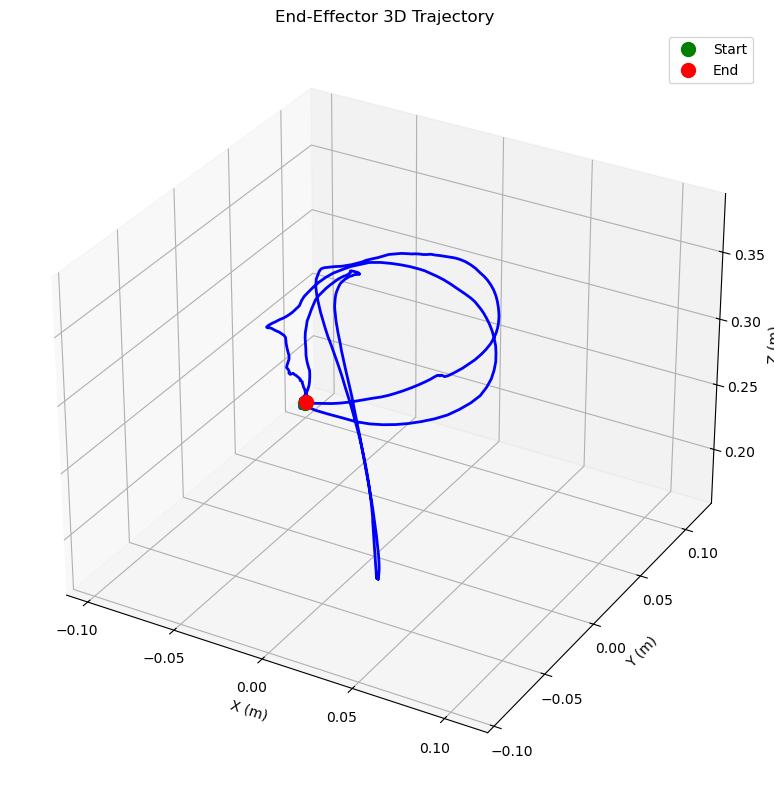

In [28]:
# Step 2: Load trajectory data and visualize 3D trajectory
# ============================================================================
# This cell:
# - Loads the trajectory data from the HDF5 file
# - Extracts end-effector positions and orientations
# - Creates a 3D visualization of the robot's trajectory
# - Shows the start and end points of the movement

# Load trajectory data from HDF5 file
trajectory_data = load_trajectory_data(episode_info)

if trajectory_data and trajectory_data['cartesian_positions'] is not None:
    # Extract position (XYZ) and orientation (roll, pitch, yaw) from cartesian positions
    positions, orientations = extract_orientation_from_cartesian(trajectory_data['cartesian_positions'])
    
    # Visualize 3D trajectory with start and end points highlighted
    visualize_trajectory_3d(positions)


Using Euler angles format [x, y, z, yaw, pitch, roll]


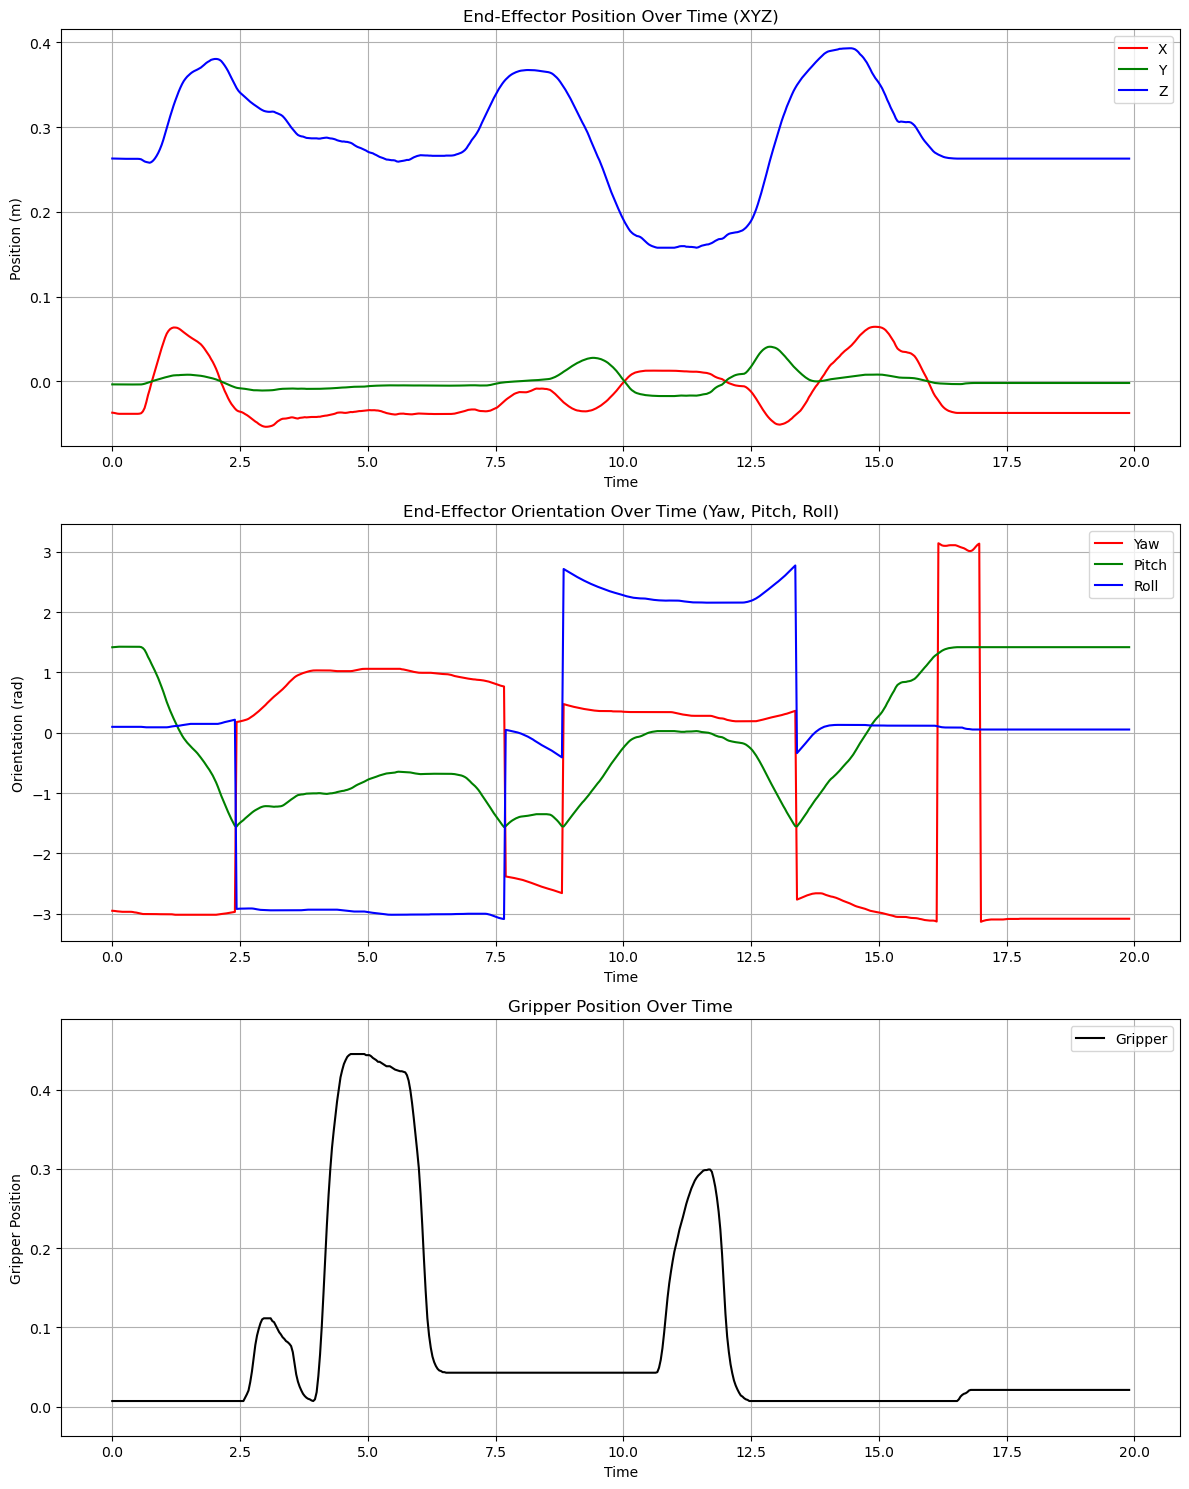

In [29]:
# Step 3: Visualize position and orientation time series
# ============================================================================
# This cell:
# - Creates separate plots for position (XYZ) and orientation (Roll, Pitch, Yaw)
# - Plots the data over time to show the temporal evolution of movement
# - Includes gripper state if available
# - This split view makes it easier to analyze each component independently

if trajectory_data and trajectory_data['cartesian_positions'] is not None:
    # Extract position (XYZ) and orientation (roll, pitch, yaw) from cartesian positions
    positions, orientations = extract_orientation_from_cartesian(trajectory_data['cartesian_positions'])
    
    # Visualize position and orientation as separate time series plots
    visualize_position_time_series(
        trajectory_data['timestamps'],  # Time points
        positions,                      # XYZ position (meters)
        orientations,                   # Roll, Pitch, Yaw (radians)
        trajectory_data['gripper_positions']  # Gripper state
    )


In [30]:
def display_video_frames(frames, cols=5):
    """
    Display a list of video frames in a grid layout
    
    This function:
    1. Takes a list of frames (numpy arrays in RGB format)
    2. Organizes them into a grid with the specified number of columns
    3. Displays the grid using matplotlib
    
    Args:
        frames: List of frames as numpy arrays in RGB format
        cols: Number of columns in the grid
    """
    if not frames:
        print("No frames to display")
        return
    
    # Calculate number of rows needed
    n = len(frames)
    rows = (n + cols - 1) // cols
    
    # Create figure with subplots
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    
    # Make axes a 2D array even if there's only one row or column
    if rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot each frame
    for i, frame in enumerate(frames):
        if i < rows * cols:
            r, c = i // cols, i % cols
            axes[r, c].imshow(frame)
            axes[r, c].set_title(f"Frame {i}")
            axes[r, c].axis('off')
    
    # Hide empty subplots
    for i in range(len(frames), rows * cols):
        r, c = i // cols, i % cols
        axes[r, c].axis('off')
    
    plt.tight_layout()
    plt.show()

def load_video_frames_with_pyav(episode_info, num_frames=5):
    """
    Load frames from the video file associated with the episode using PyAV
    
    This function is an alternative to the OpenCV-based video loading function,
    particularly useful for videos with AV1 codec that OpenCV might struggle with.
    
    PyAV provides more robust codec support and can handle a wider range of
    video formats. The function:
    
    1. Attempts to import PyAV (requires installation: pip install av)
    2. Extracts the video path from episode metadata
    3. Opens the video using PyAV's container
    4. Samples frames evenly throughout the video
    5. Converts PyAV frames to numpy arrays in RGB format
    
    Args:
        episode_info: Dictionary containing episode information
        num_frames: Number of frames to sample from the video
        
    Returns:
        list: List of sampled frames as numpy arrays in RGB format
    """
    try:
        import av
    except ImportError:
        print("PyAV is not installed. Please install it with: pip install av")
        return None
    
    if not episode_info or 'metadata' not in episode_info or not episode_info['metadata']:
        print("No metadata available")
        return None
    
    # Get video path from metadata
    if 'left_mp4_path' not in episode_info['metadata']:
        print("No video path found in metadata")
        return None
    
    video_path = episode_info['metadata']['left_mp4_path']
    
    # Make sure the path is absolute
    if not os.path.isabs(video_path):
        video_path = os.path.join(episode_info['path'], video_path)
    
    if not os.path.exists(video_path):
        print(f"Video file not found: {video_path}")
        return None
    
    try:
        # Use PyAV to read the video
        container = av.open(video_path)
        stream = container.streams.video[0]
        
        # Get video properties
        width = stream.width
        height = stream.height
        fps = stream.average_rate
        frame_count = stream.frames
        
        print(f"Video properties: {width}x{height}, {fps} fps, {frame_count} frames")
        
        # Sample frames evenly throughout the video
        frames = []
        if frame_count > 0:
            # Calculate frame indices to sample
            indices = np.linspace(0, frame_count - 1, num_frames, dtype=int)
            
            for i, frame in enumerate(container.decode(stream)):
                if i in indices:
                    # Convert PyAV frame to numpy array
                    img = frame.to_ndarray(format='rgb24')
                    frames.append(img)
                
                # Stop once we've collected all the frames we need
                if len(frames) == num_frames:
                    break
            
            if not frames:
                print("WARNING: No frames were loaded")
        else:
            print("WARNING: Video has no frames")
        
        container.close()
        return frames
    
    except Exception as e:
        print(f"Error loading video with PyAV: {e}")
        return None


PyAV is installed, trying to load frames with PyAV...
Video properties: 640x480, 30 fps, 598 frames
Successfully loaded frames with PyAV


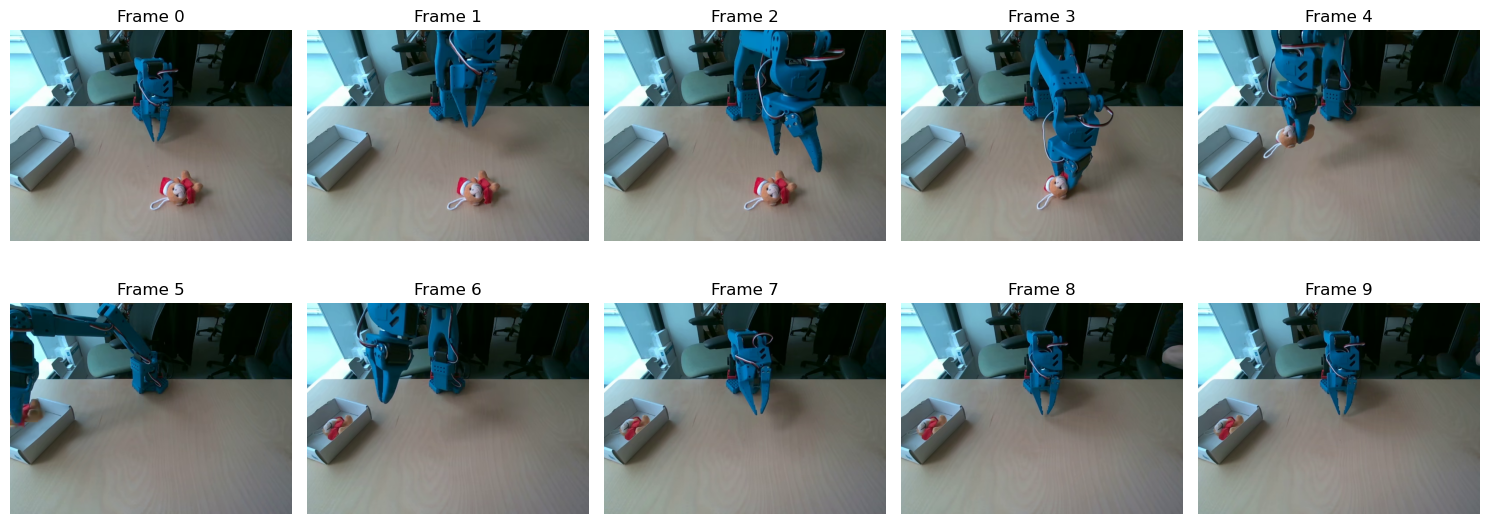

In [31]:
# Step 4:  video loading using PyAV
# ============================================================================
# This cell:
# - Attempts to load video frames using PyAV instead of OpenCV
# - PyAV often has better codec support, especially for AV1 videos
# - Samples 10 frames evenly distributed throughout the video
# - Displays the frames in a grid layout if successful
# - Requires PyAV to be installed (pip install av)

# Try loading video frames with PyAV (alternative method)
try:
    import av
    print("PyAV is installed, trying to load frames with PyAV...")
    frames_pyav = load_video_frames_with_pyav(episode_info, num_frames=10)
    if frames_pyav:
        print("Successfully loaded frames with PyAV")
        display_video_frames(frames_pyav)
    else:
        print("Failed to load frames with PyAV")
except ImportError:
    print("PyAV is not installed. You can install it with: pip install av")
